In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("./Data/final_data.csv")
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [3]:
#It represents the unique ids of each users
data.useridx.unique()

array([   14,    16,    20, ..., 88187, 88189, 88190], shape=(33530,))

In [4]:
#This represent a transaction id of a transaction, one user can have multiple transactions
data.transactionid.unique()

array([ 5661, 67652, 68777, ..., 18240, 40525, 72057], shape=(52930,))

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   useridx            52930 non-null  int64
 1   continent          52930 non-null  str  
 2   region             52930 non-null  str  
 3   usercountry        52930 non-null  str  
 4   usercity           52922 non-null  str  
 5   transactionid      52930 non-null  int64
 6   visityearx         52930 non-null  int64
 7   visitmonthx        52930 non-null  int64
 8   attractionidx      52930 non-null  int64
 9   ratingx            52930 non-null  int64
 10  visitmodex         52930 non-null  str  
 11  attraction         52930 non-null  str  
 12  attractionaddress  52930 non-null  str  
 13  attractiontype     52930 non-null  str  
 14  attractioncity     52930 non-null  str  
 15  attractioncountry  52930 non-null  str  
dtypes: int64(6), str(10)
memory usage: 13.1 MB


In [6]:
#Here i am dropping the nan row as the usercity feature have 8 null values
data.dropna(subset="usercity",inplace=True,axis=0)

In [7]:
#CHecking if any nan value is present
data.isna().sum()

useridx              0
continent            0
region               0
usercountry          0
usercity             0
transactionid        0
visityearx           0
visitmonthx          0
attractionidx        0
ratingx              0
visitmodex           0
attraction           0
attractionaddress    0
attractiontype       0
attractioncity       0
attractioncountry    0
dtype: int64

In [8]:
#Here i am changong the dtype of ratingx
data.ratingx=data.ratingx.astype(np.int32)
data.ratingx.dtype

dtype('int32')

In [9]:
#Here i am extracting the top10 counties where trasnactions were made by the tourists
top_10_country=data.usercountry.value_counts().sort_values(ascending=False).head(10)
top_10_country

usercountry
Australia         13322
United Kingdom     6722
United States      6261
Indonesia          4842
Singapore          2807
India              2543
Malaysia           1581
Canada             1486
New Zealand        1479
Netherlands         859
Name: count, dtype: int64

In [10]:
top_10_country_df=data[data.usercountry.isin(top_10_country.index)]
top_10_country_df.head(2)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


<Axes: ylabel='usercountry'>

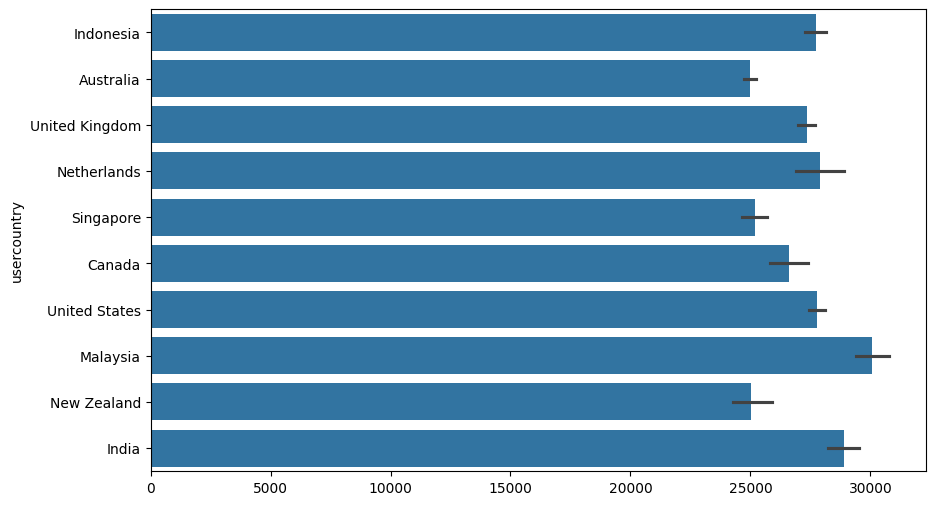

In [11]:
#Here i am plotting the top10 countries where the majority of the transactions were made by the tourists for a particular attraction
plt.figure(figsize=(10,6))
sns.barplot(top_10_country_df.usercountry)

### Report 
- Majority of revenue from tourism is generated from USA, UK, India, Canada, Australia etc.
- This shows that most tourists visiting these attractions are from these countries.
#### Business impact
- stores can set up targeted marketing campaigns in these countries to attract more tourists.
- They can also offer special discounts or packages to tourists from these countries to encourage them to visit more attractions.
- local vendors can stock up on products that are popular among tourists from these countries.

In [12]:
continents=data.continent.value_counts()
continents

continent
Asia                   15693
Australia & Oceania    14852
Europe                 13272
America                 8187
Africa                   918
Name: count, dtype: int64

In [13]:
int(continents["Africa"])

918

([<matplotlib.patches.Wedge at 0x2092aa57380>,
 [Text(0.6562243383362469, 0.8828191308389023, 'Asia'),
  Text(-1.0145411895272733, 0.4250954889816936, 'Australia & Oceania'),
  Text(-0.3230328535443768, -1.0514988233616704, 'Europe'),
  Text(0.9109682898330369, -0.6165523294244151, 'America'),
  Text(1.0983670854035772, -0.059914486579214415, 'Africa')],
 [Text(0.3579405481834074, 0.4815377077303103, '29.65%'),
  Text(-0.5533861033785127, 0.2318702667172874, '28.06%'),
  Text(-0.17619973829693275, -0.5735448127427293, '25.08%'),
  Text(0.4968917944543837, -0.3363012705951354, '15.47%'),
  Text(0.599109319311042, -0.032680629043207864, '1.73%')])

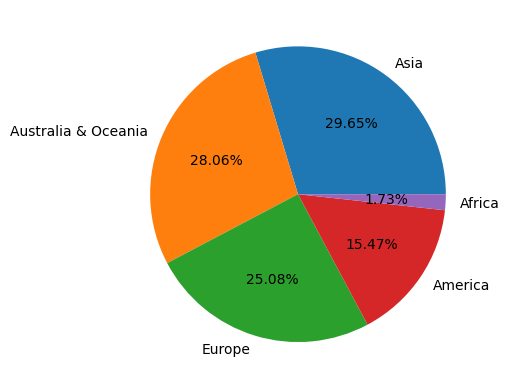

In [14]:
#Here i am plotting the spread of transactions over the continents
plt.pie(continents,labels=continents.index,autopct="%1.2f%%")

In [15]:
a=data.groupby("continent")["region"].value_counts()
a

continent            region          
Africa               Southern Africa       644
                     North Africa          182
                     East Africa            66
                     West Africa            19
                     Central Africa          7
America              Northern America     7847
                     South America         240
                     Caribbean              54
                     Central America        46
Asia                 South East Asia     10392
                     South Asia           2874
                     Middle East          1266
                     East Asia            1121
                     -                      24
                     Central Asia           16
Australia & Oceania  Australia           13322
                     Oceania              1530
Europe               Western Europe       8534
                     Central Europe       2303
                     Southern Europe       990
                     N

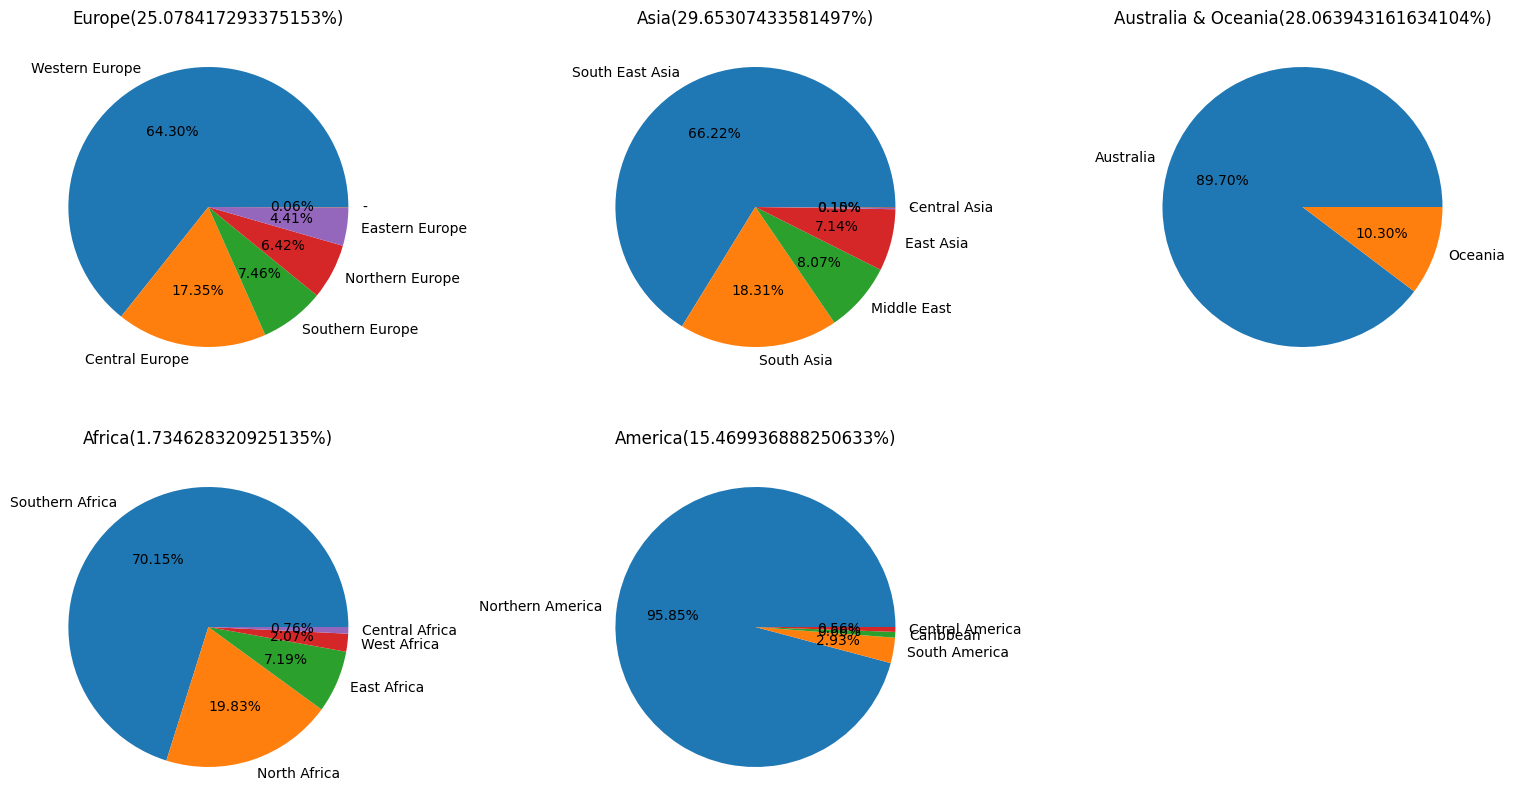

In [16]:
#Here i am plotting the continent region spread of tourists transactions
plt.figure(figsize=(20,10))
j=1
for i in data.continent.unique():
    cont=data[data.continent==i]
    val=cont.region.value_counts()
    plt.subplot(2,3,j)
    plt.pie(val,labels=val.index,autopct="%1.2f%%")
    plt.title(f"{i}({(int(continents[i])/data.shape[0])*100}%)")
    j=j+1

In [17]:
#Here i am extracting the top10 counties where trasnactions were made by the tourists
top_10_city=data.usercity.value_counts().sort_values(ascending=False).head(10)
top_10_city_df=data[data.usercity.isin(top_10_city.index)]
top_10_city

usercity
Singapore       2765
Melbourne       2225
Perth           1754
London          1580
Greenwich       1520
Sydney          1510
Jakarta         1290
Adelaide         991
Brisbane         842
Kuala Lumpur     726
Name: count, dtype: int64

<Axes: ylabel='usercity'>

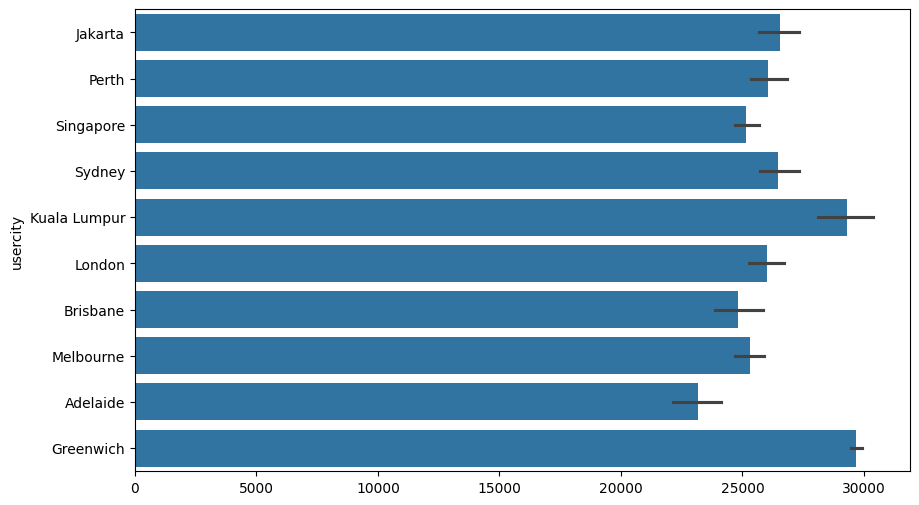

In [18]:
#Here i am plotting the top10 cities where the majority of the transactions were made by the tourists for a particular attraction
plt.figure(figsize=(10,6))
sns.barplot(top_10_city_df.usercity)

In [19]:
data.visityearx.unique()

array([2018, 2017, 2015, 2019, 2020, 2013, 2016, 2014, 2022, 2021])

In [20]:
visityear=data.visityearx.value_counts()
visityear

visityearx
2016    12818
2017     9444
2015     8687
2018     7461
2019     5912
2014     4806
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

<Axes: xlabel='visityearx', ylabel='count'>

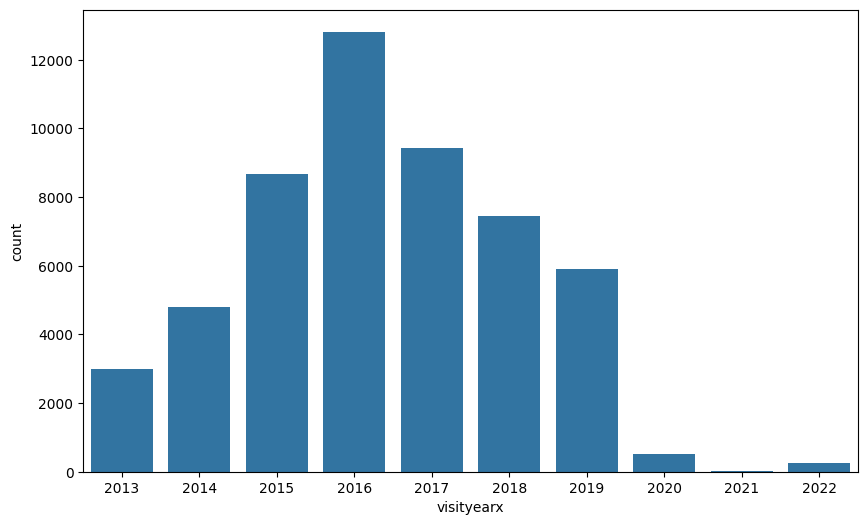

In [21]:
#Here i am plotting the barplot of the visit year of the tourists to attractions
plt.figure(figsize=(10,6))
sns.barplot(visityear)

### Report
- **2015-2017** was the peak year for tourisum which accounted for the maximum number of transactions by the tourists.
- **2020-2022** was the lowest period for tourism transactions which can be attributed to the covid-19 pandemic that led to global lockdowns and travel restrictions.
#### Business strategies
- Tourism agencies and businesses can analyze the **2015-2017** data to identify trends and patterns in tourist behavior, such as popular destinations, travel seasons, and spending habits. 
- This information can help them tailor their marketing strategies and offerings to better meet the needs and preferences of tourists.

In [22]:
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [23]:
data.groupby("visityearx")["visitmonthx"].value_counts()

visityearx  visitmonthx
2013        7              316
            12             288
            8              281
            9              271
            10             261
                          ... 
2022        5               22
            4               20
            2                7
            3                2
            1                2
Name: count, Length: 117, dtype: int64

In [ ]:
#Here i am analysing the trends of the top transactions year
topvisityear=[2016]
top_visityear=data[data.visityearx.isin(topvisityear)]
topmonth=top_visityear.visitmonthx.value_counts().sort_values(ascending=False)
topmonth
top_visityear.head(3)

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
22,34,Africa,Southern Africa,South Africa,Paarl,11243,2016,7,640,4,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
25,42,Asia,South East Asia,Singapore,Singapore,24119,2016,12,841,4,Family,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia",Water Parks,Douala,Cameroon
33,59,Europe,Southern Europe,Greece,Athens,147257,2016,7,369,3,Family,Kuta Beach - Bali,Kuta,Beaches,Douala,Cameroon


Text(0.5, 1.0, '2016 transaction spread')

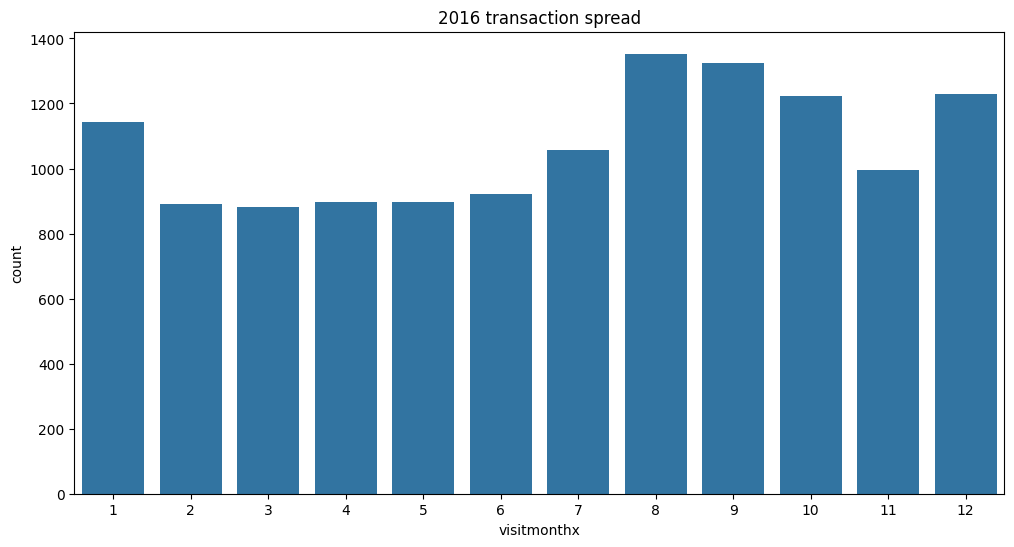

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(topmonth)
plt.title("2016 transaction spread")

Text(0.5, 1.0, 'monthly transaction spread')

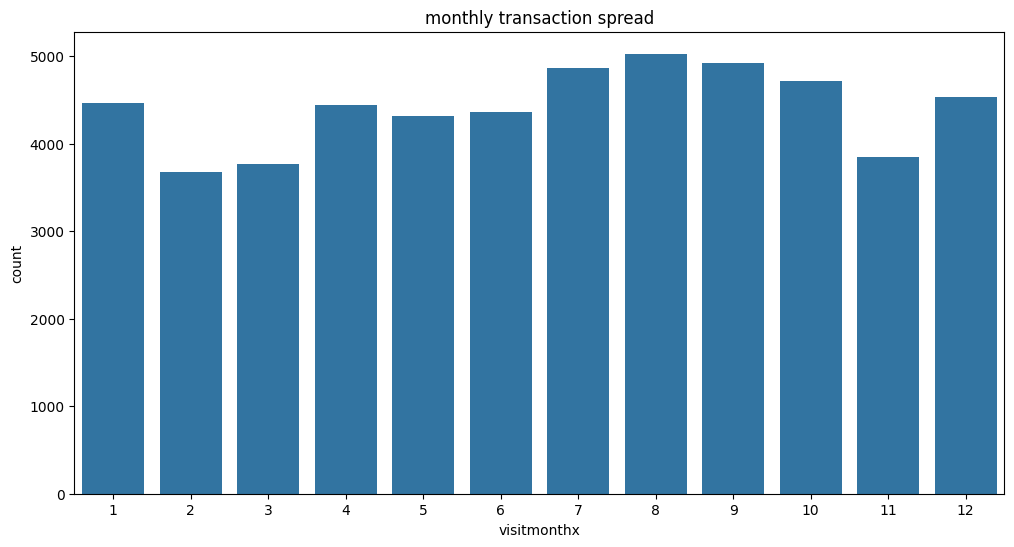

In [51]:
plt.figure(figsize=(12,6))
visitmonth=data.visitmonthx.value_counts()
sns.barplot(visitmonth)
plt.title("monthly transaction spread")

### Report 
- **July-September** is the peak months for Tourists to visit the attractions.
- The tourists visit over the year is all good for attractions.
#### Business strategy:
- The tourism department can focus their marketing and promotional efforts during the peak months of July to September to attract more tourists.
- locals can be encouraged to visit attractions during the off-peak months through special discounts and offers.
- local vendors can plan their inventory and staffing based on the expected tourist influx during these peak months.

In [54]:
rating=data.ratingx.value_counts()
rating

ratingx
5    23930
4    17964
3     7730
2     2035
1     1263
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2090ae06ad0>,
 [Text(0.16465051812661285, 1.0876075610626463, '5'),
  Text(-0.7928364903848316, -0.762502655414565, '4'),
  Text(0.7256261725708605, -0.8267204229243186, '3'),
  Text(1.0599268306775527, -0.2942025044248246, '2'),
  Text(1.0969097734224982, -0.0823950785557251, '1')],
 [Text(0.089809373523607, 0.5932404878523525, '45.22%'),
  Text(-0.4324562674826354, -0.41591053931703537, '33.94%'),
  Text(0.39579609412956024, -0.45093841250417366, '14.61%'),
  Text(0.5781419076423013, -0.1604740933226316, '3.85%'),
  Text(0.598314421866817, -0.04494277012130459, '2.39%')])

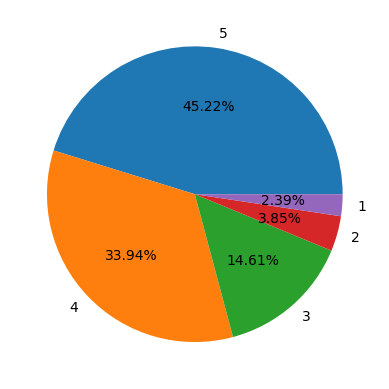

In [ ]:
#Here i am plotting the pie plot of ratings given by the tourists after their visit to the attractions
plt.pie(rating.values,labels=rating.index,autopct="%1.2f%%")

### Report
- **79.16%** of the tourists are satisfied from their visit to the attractions as they have given ratings of 4 and 5.
- This shows how the tourisum industry is growing and the tourists are happy with the services provided by the tourism industry.
#### Business strategy
- The tourism industry should focus on maintaining the quality of services provided to the tourists as a satisfied tourist is likely to revisit and recommend the attraction to others.
- For the ratings of below 4 the tourism industry should focus on improving the services provided to the tourists by taking feedback from them and implementing the changes accordingly.

In [58]:
data.visitmodex.value_counts()

visitmodex
Couples     21617
Family      15215
Friends     10944
Solo         4523
Business      623
Name: count, dtype: int64

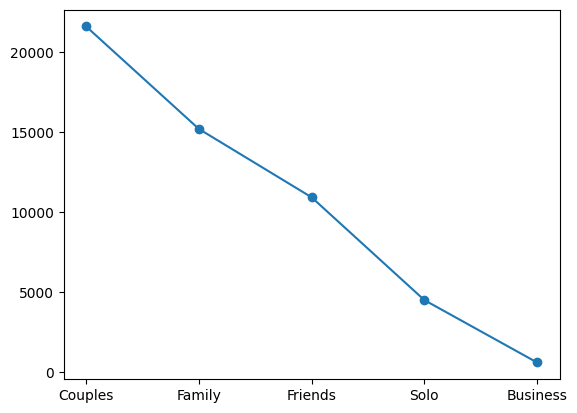

In [63]:
plt.plot(data.visitmodex.value_counts(),marker="o")

### Report
- **Couples and family** are the majority of the tourists visiting the attractions.
- *Business* is the least category of tourists visiting the attractions.
#### Business strategy
- The business category tourists can be targeted more by providing them special packages and offers.
- The couple and friend category tourists can be targeted by providing them special discounts on group bookings.

In [ ]:
#Here i am calculating the percentage of transactions made for each attraction
for i in data.attraction.value_counts().index:
    print(f"{i}: {(data.attraction.value_counts()[i]/data.shape[0])*100}%")

Sacred Monkey Forest Sanctuary: 24.936699293299572%
Waterbom Bali: 12.14806696647897%
Tegalalang Rice Terrace: 10.980310645856166%
Uluwatu Temple: 6.347076830051774%
Tanah Lot Temple: 6.333849816711387%
Sanur Beach: 5.7499716563999845%
Seminyak Beach: 5.5024375496013%
Kuta Beach - Bali: 5.224670269453158%
Merapi Volcano: 4.223196402252372%
Tegenungan Waterfall: 4.138165602207022%
Nusa Dua Beach: 3.9756622954536867%
Malioboro Road: 2.501795094667624%
Ullen Sentalu Museum: 1.8480027209856014%
Yogyakarta Palace: 1.5078795208042024%
Bromo Tengger Semeru National Park: 0.7199274403839613%
Ramayana Ballet at Prambanan: 0.7123691470465969%
Sewu Temple: 0.7123691470465969%
Water Castle (Tamansari): 0.7048108537092325%
Ratu Boko Temple: 0.3854729602055856%
Jomblang Cave: 0.2550924001360493%
Kalibiru National Park: 0.24564453346434373%
Mount Semeru Volcano: 0.15683458675031178%
Malang City Square: 0.12093269339783076%
Coban Rondo Waterfall: 0.10392653338876083%
Goa Cina Beach: 0.1020369600544197

### Repport 
- Out of **1698** total attractions tourists made transactions for only **30** attractions.
- This indicates that a small number of attractions are very popular among tourists, while the majority receive relatively few visits.
#### Business strategy
- To capitalize on the popularity of the top attractions, targeted marketing campaigns and promotional offers can be developed to attract more tourists.
- For the less popular attractions, efforts can be made to enhance their visibility through partnerships with travel.
- For the less popular attractions, tourism boards can collaborate with local businesses to create attractive packages and experiences that highlight these lesser-known sites.

In [68]:
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [76]:
#Here i am calculating the percentage of transactions made for each attractiontype
for i in data.attractiontype.value_counts().index:
    print(f"{i}: {(data.attractiontype.value_counts()[i]/data.shape[0])*100}%")

Nature & Wildlife Areas: 25.036846680019654%
Beaches: 20.62280337099883%
Religious Sites: 12.68092664676316%
Water Parks: 12.14806696647897%
Points of Interest & Landmarks: 11.806054192963229%
Volcanos: 4.380030989002683%
Waterfalls: 4.242092135595783%
Flea & Street Markets: 2.501795094667624%
History Museums: 1.8480027209856014%
Historic Sites: 1.5078795208042024%
Ancient Ruins: 1.0978421072521825%
National Parks: 0.9655719738483051%
Ballets: 0.7123691470465969%
Caverns & Caves: 0.2550924001360493%
Neighborhoods: 0.08314122671100865%
Speciality Museums: 0.05857677336457427%
Spas: 0.052908053361550966%


In [85]:
#Here i am extracting the top10 attraction types which were most visited by the tourists.
top10attractiontype=data.attractiontype.value_counts().sort_values(ascending=False).head(10)
top10attractiontype

attractiontype
Nature & Wildlife Areas           13250
Beaches                           10914
Religious Sites                    6711
Water Parks                        6429
Points of Interest & Landmarks     6248
Volcanos                           2318
Waterfalls                         2245
Flea & Street Markets              1324
History Museums                     978
Historic Sites                      798
Name: count, dtype: int64

<Axes: xlabel='attractiontype', ylabel='count'>

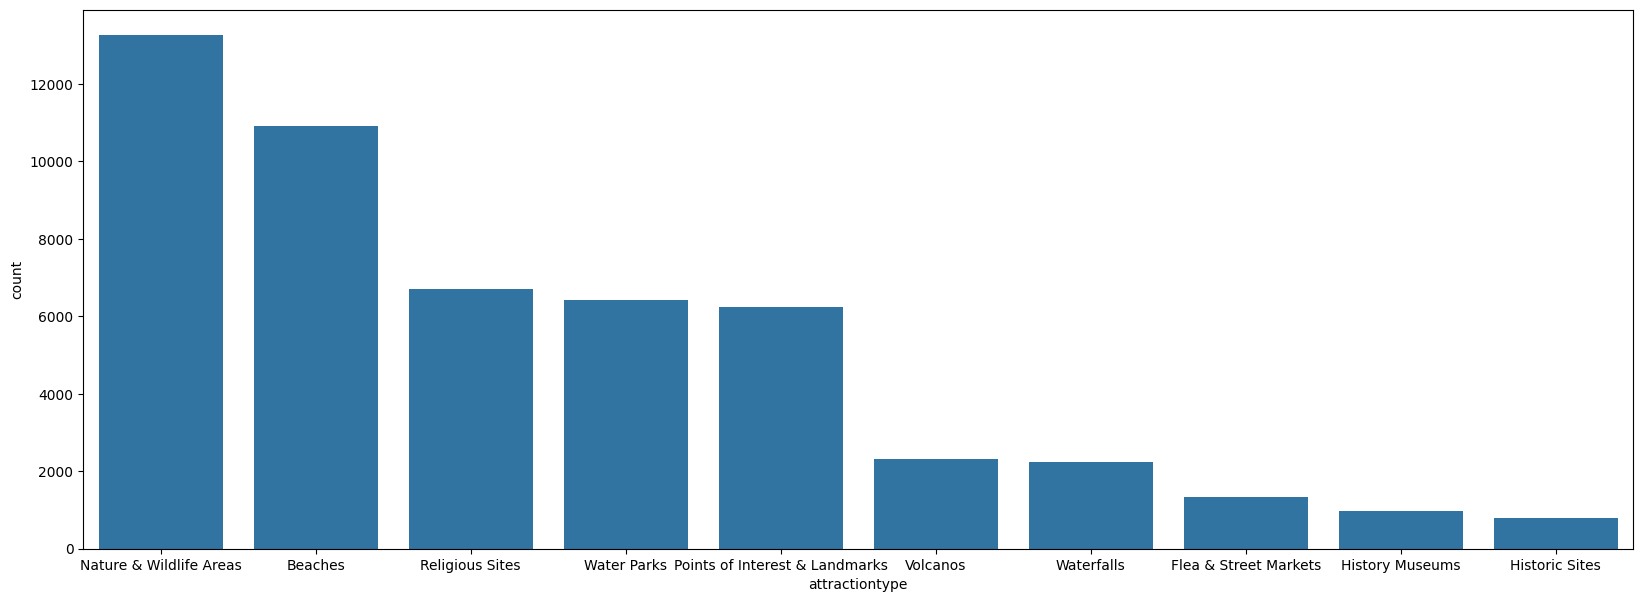

In [82]:
plt.figure(figsize=(20,7))
sns.barplot(top10attractiontype)

### Report 
- Out of these **30** attractions the most visisted attraction type is **Nature & Wildlife Areas** followed by **Beaches** and **Religious Sites**.
- They account for nearly **58%** of the total transactions made by the tourists.
- **Spas** are the least visited attraction type among all.
#### Business Strategies
- Based on the analysis its clear that tourists are more inclined towards nature and wildlife areas,beaches and religious sites. So the business can focus on these attraction types more to increase the number of transactions.
- For the less visited attraction types like spas, the business can offer discounts or special packages to attract more tourists.

In [91]:
attractioncountry=data.attractioncountry.value_counts()
attractioncountry

attractioncountry
Cameroon    45991
Chad         6931
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2090e7efed0>,
 [Text(-1.0081992879251578, 0.43992521617566405, 'Cameroon'),
  Text(1.0081993263846394, -0.43992512803607786, 'Chad')],
 [Text(-0.5499268843228133, 0.23995920882308946, '86.90%'),
  Text(0.5499269053007123, -0.2399591607469515, '13.10%')])

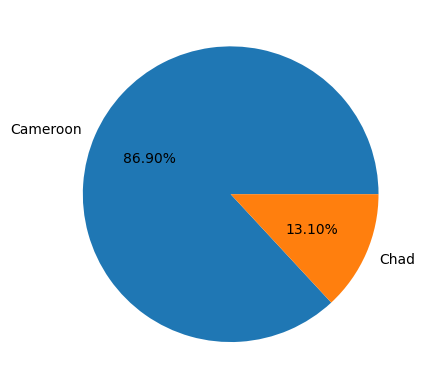

In [ ]:
#Here i am plotting the pie chart of attraction country where the majority of the transactions were made by the tourists
plt.pie(attractioncountry,labels=attractioncountry.index,autopct="%1.2f%%")

### Report 
- Out of the 30 attraction visited by tourists, these attraction are located in two countries **Cameroon and chad**.
- Cameroon has the highest number of tourist attractions visited as compared to Chad.
#### Business strategies
- The tourism department of Cameroon can focus on improving the facilities and infrastructure of these top attractions to enhance the overall tourist experience.
- Marketing campaigns can be designed to promote these attractions internationally, attracting more tourists and boosting the local economy.
- For the attractions in Chad, efforts can be made to identify and address any barriers that may be preventing tourists from visiting, such as safety concerns or lack of awareness.
- Other attraction countries can also analyze the strategies implemented by Cameroon to attract tourists and adapt them to their own tourism promotion efforts.

In [94]:
attractioncity=data.attractioncity.value_counts()
attractioncity

attractioncity
Douala          45162
N'Djamena        6931
South Region      829
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2090e83f4d0>,
 [Text(-0.9853379598920219, 0.48898783706328364, 'Douala'),
  Text(0.9600908734048249, -0.5368663844987509, "N'Djamena"),
  Text(1.0986683036857967, -0.05411061334132128, 'South Region')],
 [Text(-0.5374570690320118, 0.2667206383981547, '85.34%'),
  Text(0.5236859309480862, -0.29283620972659136, '13.10%'),
  Text(0.5992736201922527, -0.029514880004357057, '1.57%')])

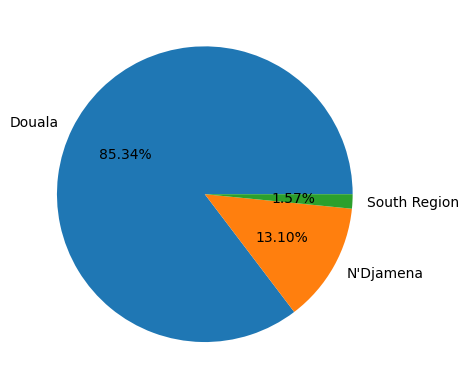

In [95]:
#Here i am plotting the pie chart of attraction city where the majority of the transactions were made by the tourists
plt.pie(attractioncity,labels=attractioncity.index,autopct="%1.2f%%")

### Report 
- Out of the 30 attraction visited by tourists, these attraction are located in three cities **Douala, South Region and N' Djamena**.
- Douala has the highest number of tourist attractions visited as compared to other two.
#### Business strategies
- The tourism department of Douala can focus on improving the facilities and infrastructure of these top attractions to enhance the overall tourist experience.
- Marketing campaigns can be designed to promote these attractions internationally, attracting more tourists and boosting the local economy.
- For the attractions in other cities, efforts can be made to identify and address any barriers that may be preventing tourists from visiting, such as safety concerns or lack of awareness.
- Other attraction cities can also analyze the strategies implemented by Douala to attract tourists and adapt them to their own tourism promotion efforts.